In [1]:
library(conText)
library(quanteda)
library(dplyr)
library(ggplot2)

conText v3.0.1 successfully loaded. Note this version of the package comes with significant changes to the conText() function.
                        See Quick Start Guide for help getting started and instructions for accessing older versions of the package:
 https://github.com/prodriguezsosa/conText/blob/master/vignettes/quickstart.md

Package version: 4.3.1
Unicode version: 15.0
ICU version: 73.2

Parallel computing: disabled

See https://quanteda.io for tutorials and examples.


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




### Politicization score

In [2]:
results_df <- readRDS("Results_Files/ALC_ideology_results_df.rds")
results_df_party <- readRDS("Results_Files/ALC_party_results_df.rds")

In [3]:
# Create politicization score
results_df <- results_df %>%  
    filter(frequency >= 10) %>%
    mutate(pol_score = (cos_liberal_mean + cos_con_mean)/2,
           pol_score_upper = (cos_liberal_upper + cos_con_upper)/2,
           pol_score_lower = (cos_liberal_lower + cos_con_lower)/2) %>%
    mutate(group = "ideology") %>%
    select("term", "year", "topic", "label", "pol_score", "pol_score_upper", "pol_score_lower", "group", "frequency")

results_df_party <- results_df_party %>%
   filter(frequency >= 10) %>%
    mutate(pol_score = (cos_dem_mean + cos_rep_mean)/2,
           pol_score_upper = (cos_dem_upper + cos_rep_upper)/2,
           pol_score_lower = (cos_dem_lower + cos_rep_lower)/2) %>%
    mutate(group = "party") %>%
    select("term", "year", "topic", "label", "pol_score", "pol_score_upper", "pol_score_lower", "group", "frequency")

In [4]:
cor(results_df$pol_score, results_df$frequency, use="complete.obs")

[1] 0.5202219

In [5]:
cor(results_df_party$pol_score, results_df_party$frequency, use="complete.obs")

[1] 0.5136217

### Create bigger categories

In [6]:
results_df_cat <- 
    rbind(results_df, results_df_party) %>%
    mutate(Category = case_when(
      label %in% c("Abortion", "Gender", "LGBTQ", "Marriage", "Parenting") ~ "Gender and Family",
      label %in% c("Catholicism", "Religion") ~ "Religion",
      label %in% c("Minority", "Native_American", "Racial", "Confederate", "Immigration") ~ "Race and Immigration",
      label %in% c("Campaigns & Donors", "Protest", "PublicOpinion", "Senate", "Elections") ~ "Politics",
      label %in% c("CriminalJustice", "Investigation", "Criminal", "Burglary", 
                   "Homicide", "Police") ~ "Crime and Policing",
      label %in% c("Constitution_Law", "Judicial", "Lawsuit", "SupremeCourt") ~ "Legal Institution",
      label %in% c("Higher_Education", "Education") ~ "Education",
      label %in% c("Science") ~ "Science",
      label %in% c("Gun_Control") ~ "Gun",
      label %in% c("Bankruptcy", "Banks", "Commodity_Market", "Corporate", "CorporateFinance",
                   "Earnings", "ExecutiveCompensation", "Financial", "Investing", "Money_Markets",
                   "Retail", "Securities",
                   "Stock_market", "Foreign_exchange") ~ "Financial Market",
      label %in% c("Welfare & Poverty", "Taxation", "Economics", "Agriculture", "Business",
                   "Economy", "Fiscal", "Labor", "Workers", "MonetaryPolicy", "Trade") ~ "Economic Issues",
      label %in% c("Housing", "Urban_development", "Mortgage", "Architecture") ~ "Housing",
      label %in% c("China", "Espionage", "Latin_America", "Middle_East",
                   "MiddleEastConflict", "Military", "NuclearArms", "Terrorism", "Russia & Ukraine") ~ "Foreign Affairs",
      label %in% c("ClimateChange", "Disaster", "Air Pollution",
                   "Weather", "Wildfires") ~ "Environment",
      label %in% c("Healthcare", "Hospital", "MentalHealth", "Nutrition", "Pharmaceuticals",
                   "Substance Abuse", "Vaccine", "Disease") ~ "Health",
      label %in% c("Art",  "Broadway",  "Classical_Music", 
                      "Museum", "Fashion", 
                      "Literature", "Movie", "Music") ~ "Creative Arts",
      label %in% c("Festival", "TravelIndustry", "Horticulture", "Nature", "Gaming") ~ "Leisure",
      label %in% c("Culinary", "Dining",  "Wine", "Beverage") ~ "Food & Drinks",
      label %in% c("Journalism", "Radio", "Television", "TV_Entertainment") ~ "Media",
      label %in% c("AmericanFootball", "Baseball", "NBA", "NFL", "Boxing",
                   "CollegeSports", "Golf", "NHL", "Soccer",  "Tennis") ~ "Sports",
      label %in% c("Electricity", "Energy", "Postal_service",  "Telecommunications", "Water") ~ "Infrastructure",
      label %in% c("Maritime",  "Mass_Transit", "Airline", "Automotive",
                    "Railroad", "Traffic", "Transportation") ~ "Transportation",
      label %in% c("Animal", "Marine_Biology",  "Wildlife") ~ "Animals",
      label %in% c("Home", "Household", "Cooking") ~ "Home",
      label == "Space" ~ "Outer Space",
      TRUE ~ "Other"))

## Approach 1: increase minimum frequency threshold

### Overall Graph

`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


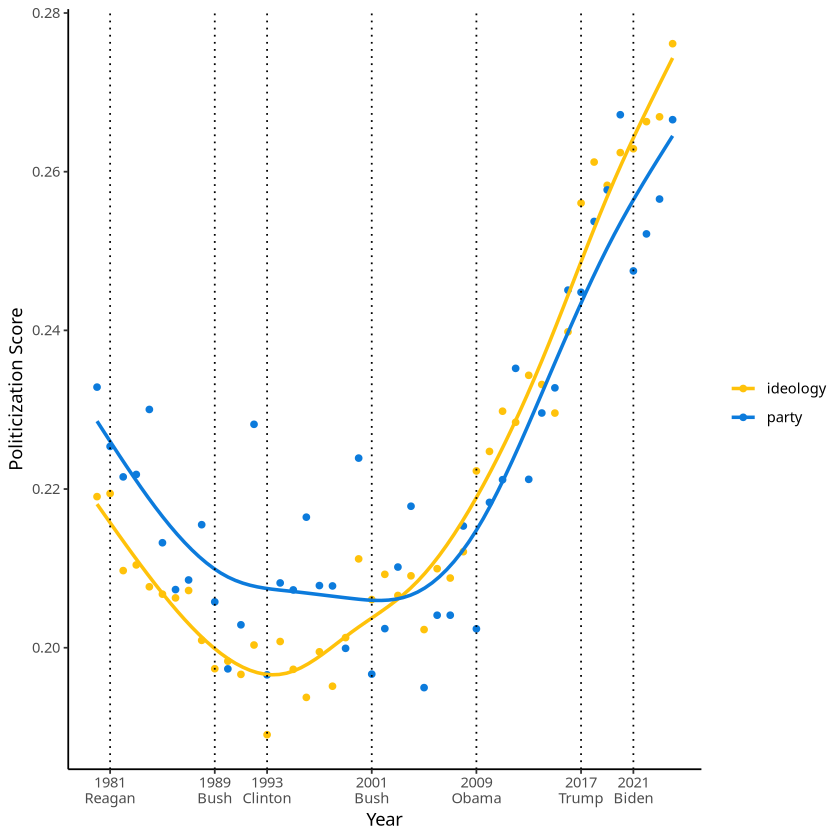

In [7]:
president <- data.frame(xintercepts = c(1981, 1989, 1993, 2001, 2009, 2017, 2021))

results_df_cat %>%
    filter(frequency >= 100) %>%  ## appear at least 300 times in any given year
    group_by(year, group) %>%
    summarise(value_avg = mean(pol_score, na.rm=TRUE)) %>%
    ungroup() %>%
    ggplot(aes(x= year, y=value_avg, color = group)) +
    geom_point() +
    geom_smooth(method = "gam", se=FALSE) +
    geom_vline(data = president, aes(xintercept = xintercepts), linetype = "dotted") +
    scale_x_continuous(
        breaks = c(1981, 1989, 1993, 2001, 2009, 2017, 2021),
        labels = c("1981\nReagan", "1989\nBush", "1993\nClinton",
                   "2001\nBush", "2009\nObama", "2017\nTrump", "2021\nBiden")) +
    scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
    theme_classic() +
    labs(x = "Year",
         y = "Politicization Score") + 
    guides(color = guide_legend(title = "")) +
    theme(plot.title = element_text(size= 20), 
          plot.subtitle=element_text(size=18), 
          strip.text = element_text(size = 15))

In [12]:
ggsave("FigureJ1_politicization_overall_highfreq.png")

Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


### Graph - Most and Least Politicized

In [8]:
category_year <- results_df_cat %>%
  filter(frequency >= 100) %>%
  group_by(year, Category, group) %>%
  summarise(
    value_avg   = mean(pol_score,   na.rm = TRUE),
    value_upper = mean(pol_score_upper, na.rm = TRUE),
    value_lower = mean(pol_score_lower, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(year0 = year - 1980)

head(category_year)

year,Category,group,value_avg,value_upper,value_lower,year0
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1980,Animals,ideology,0.2256198,0.2507670,0.2013862,0
1980,Animals,party,0.2400969,0.2632825,0.2155411,0
1980,Creative Arts,ideology,0.2304252,0.2527304,0.2079916,0
1980,Creative Arts,party,0.2187182,0.2392562,0.1981536,0
1980,Crime and Policing,ideology,0.1882702,0.2100812,0.1656351,0
1980,Crime and Policing,party,0.2344195,0.2558455,0.2129281,0


In [9]:
polscore_cat_rawvalues <- 
  category_year %>%
  group_by(Category, group) %>%
  summarise(
    early_value  = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_upper  = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower  = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  arrange(desc(late_value))

`summarise()` has grouped output by 'Category'. You can override using the
`.groups` argument.


In [10]:
order_ideo <-
    polscore_cat_rawvalues %>% 
    filter(group == "ideology") %>%
    arrange(desc(late_value))

order_ideo

Category,group,early_value,early_upper,early_lower,late_value,late_upper,late_lower
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Politics,ideology,0.3390058,0.3663237,0.3125114,0.3990170,0.4228416,0.3767174
Race and Immigration,ideology,0.2812350,0.3085765,0.2546790,0.3358755,0.3602905,0.3128498
Legal Institution,ideology,0.2278596,0.2514578,0.2038522,0.3226010,0.3460218,0.2995075
Religion,ideology,0.2461298,0.2742297,0.2176904,0.3201805,0.3484055,0.2928645
Gender and Family,ideology,0.2526731,0.2780207,0.2277076,0.3191114,0.3430036,0.2958258
Education,ideology,0.2443297,0.2685389,0.2199261,0.3096864,0.3321704,0.2878826
Economic Issues,ideology,0.2415898,0.2647354,0.2186730,0.2788795,0.3003566,0.2579145
Media,ideology,0.2340178,0.2578889,0.2100256,0.2729037,0.2954403,0.2506386
Foreign Affairs,ideology,0.2180261,0.2435663,0.1924357,0.2659562,0.2895027,0.2427286


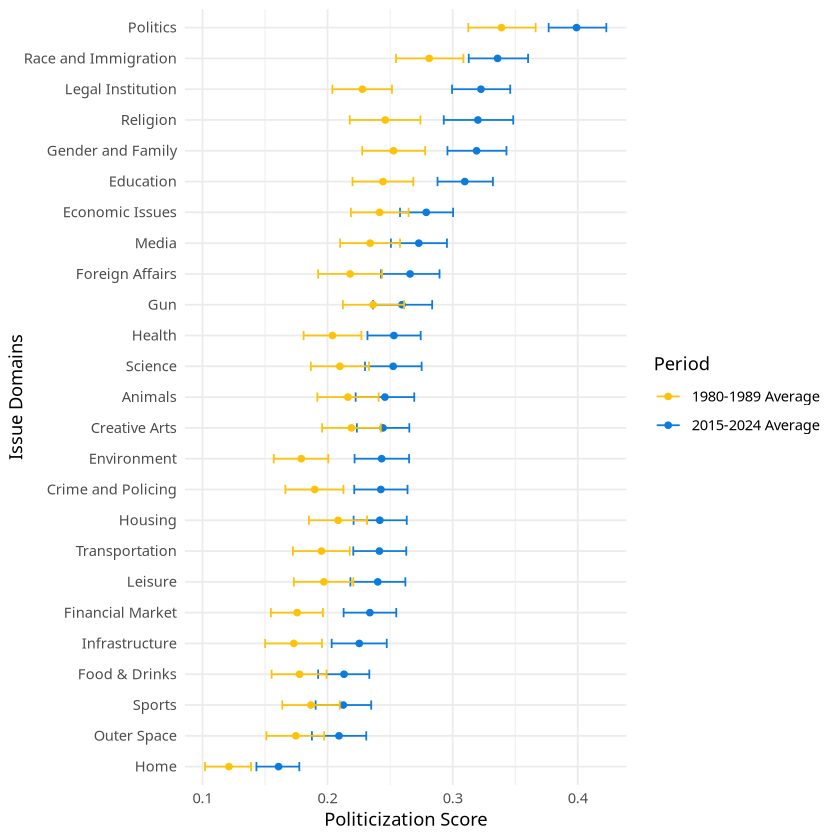

In [11]:
category_year %>%
  group_by(Category) %>%
  filter(group == "ideology") %>%
  summarise(
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_upper = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  mutate(early_rank = min_rank(desc(early_value)),
         late_rank = min_rank(desc(late_value))) %>%
  ggplot(aes(y = reorder(Category, late_value))) +
  geom_point(aes(x = late_value, color = "2015-2024 Average"),
             position = position_dodge(width = 0.3)) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper,
                    color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper,
                    color = "1980-1989 Average"), width = 0.3) +
  scale_alpha_manual(values = c(0.5, 1.0)) +
  scale_linetype_manual(values = c("dashed", "solid")) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  labs(x = "Politicization Score",
       y = "Issue Domains") +
  guides(color = guide_legend(title = "Period")) +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(size= 20), 
          plot.subtitle=element_text(size=18), 
          strip.text = element_text(size = 15))

In [35]:
ggsave("FigureJ2_politicization_ideo_HighFreq.png", width =6.5, height = 7)

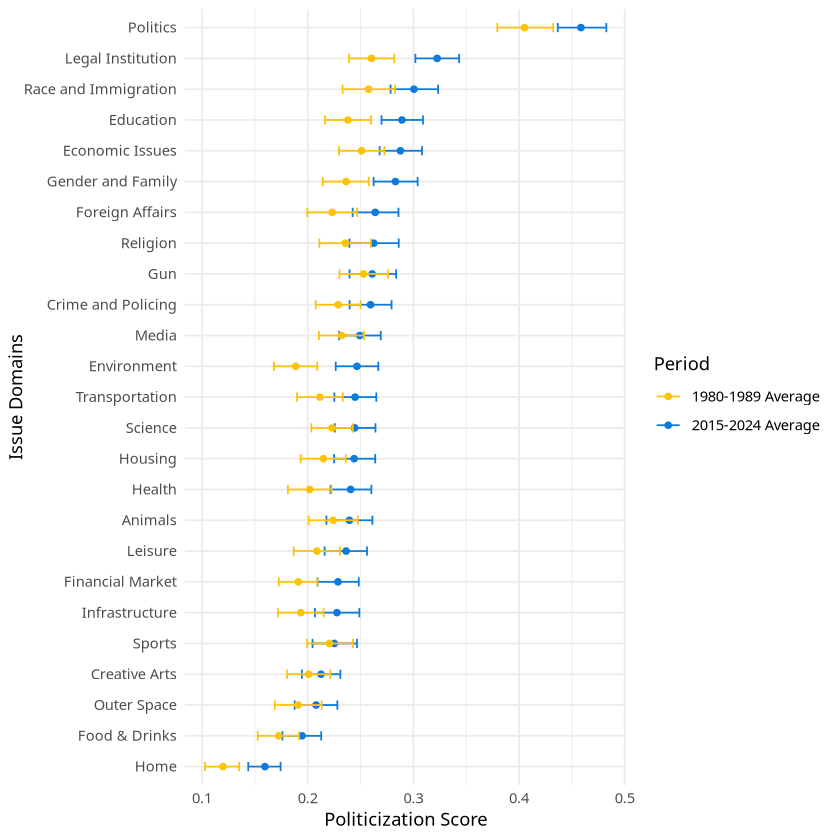

In [12]:
category_year %>%
  group_by(Category) %>%
  filter(group == "party") %>%
  summarise(
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_upper = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  mutate(early_rank = min_rank(desc(early_value)),
         late_rank = min_rank(desc(late_value))) %>%
  ggplot(aes(y = reorder(Category, late_value))) +
  geom_point(aes(x = late_value, color = "2015-2024 Average"),
             position = position_dodge(width = 0.3)) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper,
                    color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper,
                    color = "1980-1989 Average"), width = 0.3) +
  scale_alpha_manual(values = c(0.5, 1.0)) +
  scale_linetype_manual(values = c("dashed", "solid")) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  labs(x = "Politicization Score",
       y = "Issue Domains") +
  guides(color = guide_legend(title = "Period")) +
  theme_minimal() +
  theme(plot.title = element_text(size= 20), 
          plot.subtitle=element_text(size=18), 
          strip.text = element_text(size = 15))

In [37]:
ggsave("FigureJ3_politicization_party_HighFreq.png", width = 6.5, height = 7)

## Approach 2: Residualized trend

Regress pol_score on frequency, keep the residuals as a frequency-adjusted score, and replot the overall trend using that adjusted score.

In [13]:
## Frequency model - residuals become the frequency-adjusted score.
freq_model_ideo  <- lm(pol_score ~ frequency, data = results_df,       na.action = na.exclude)
freq_model_party <- lm(pol_score ~ frequency, data = results_df_party, na.action = na.exclude)

results_df$pol_score_adj       <- resid(freq_model_ideo)  + mean(results_df$pol_score,       na.rm = TRUE)
results_df_party$pol_score_adj <- resid(freq_model_party) + mean(results_df_party$pol_score, na.rm = TRUE)

## Shift the existing CI bounds by the same recentering delta -- the adjustment only corrects
## the point estimate's frequency-driven bias, not the underlying sampling variability, so the
## CI half-width is preserved.
results_df$pol_score_upper_adj       <- results_df$pol_score_upper       + (results_df$pol_score_adj       - results_df$pol_score)
results_df$pol_score_lower_adj       <- results_df$pol_score_lower       + (results_df$pol_score_adj       - results_df$pol_score)
results_df_party$pol_score_upper_adj <- results_df_party$pol_score_upper + (results_df_party$pol_score_adj - results_df_party$pol_score)
results_df_party$pol_score_lower_adj <- results_df_party$pol_score_lower + (results_df_party$pol_score_adj - results_df_party$pol_score)

## Sanity check: the frequency correlation should collapse toward zero after adjustment
cor(results_df$pol_score_adj,       results_df$frequency,       use = "complete.obs")
cor(results_df_party$pol_score_adj, results_df_party$frequency, use = "complete.obs")

[1] -6.775593e-19

[1] -4.312749e-19

In [20]:
head(results_df)

term,year,topic,label,pol_score,pol_score_upper,pol_score_lower,group,frequency,pol_score_adj,pol_score_upper_adj,pol_score_lower_adj
<chr>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
business,1980,1,Business,0.4996910,0.5111170,0.4862844,ideology,9129,-0.11374133,-0.10231526,-0.1271478
business,1981,1,Business,0.4959656,0.5113003,0.4836161,ideology,9690,-0.15634477,-0.14101013,-0.1686943
business,1982,1,Business,0.4780414,0.4935498,0.4641365,ideology,9812,-0.18272374,-0.16721542,-0.1966287
business,1983,1,Business,0.4739671,0.4909335,0.4565250,ideology,9413,-0.15914677,-0.14218038,-0.1765889
business,1984,1,Business,0.4792873,0.4952828,0.4619416,ideology,8453,-0.08729723,-0.07130167,-0.1046428
business,1985,1,Business,0.4778477,0.4968543,0.4632998,ideology,8905,-0.12006106,-0.10105447,-0.1346090


In [14]:
## Does the year trend survive frequency-adjustment?
summary(lm(pol_score     ~ year, data = results_df))$coefficients["year", ]
summary(lm(pol_score_adj ~ year, data = results_df))$coefficients["year", ]

Estimate   Std. Error      t value     Pr(>|t|) 
1.527773e-03 1.677018e-05 9.110061e+01 0.000000e+00

Estimate   Std. Error      t value     Pr(>|t|) 
1.216929e-03 1.437631e-05 8.464823e+01 0.000000e+00

In [15]:
## Carry the adjusted score (and its shifted CI bounds) onto the categorized data used for the figures
results_df_cat_adj <- results_df_cat %>%
  left_join(
    bind_rows(
      select(results_df,       term, year, group, pol_score_adj, pol_score_upper_adj, pol_score_lower_adj),
      select(results_df_party, term, year, group, pol_score_adj, pol_score_upper_adj, pol_score_lower_adj)
    ),
    by = c("term", "year", "group")
  )

In [21]:
results_df_cat_adj %>%
    group_by(year, group) %>%
    summarise(value_avg = mean(pol_score_adj, na.rm=TRUE)) %>%
    ungroup()

`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


year,group,value_avg
<dbl>,<chr>,<dbl>
1980,ideology,0.1760805
1980,party,0.1865226
1981,ideology,0.1759281
1981,party,0.1791974
1982,ideology,0.1700528
1982,party,0.1780731
1983,ideology,0.1716829
1983,party,0.1796767
1984,ideology,0.1685919


`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


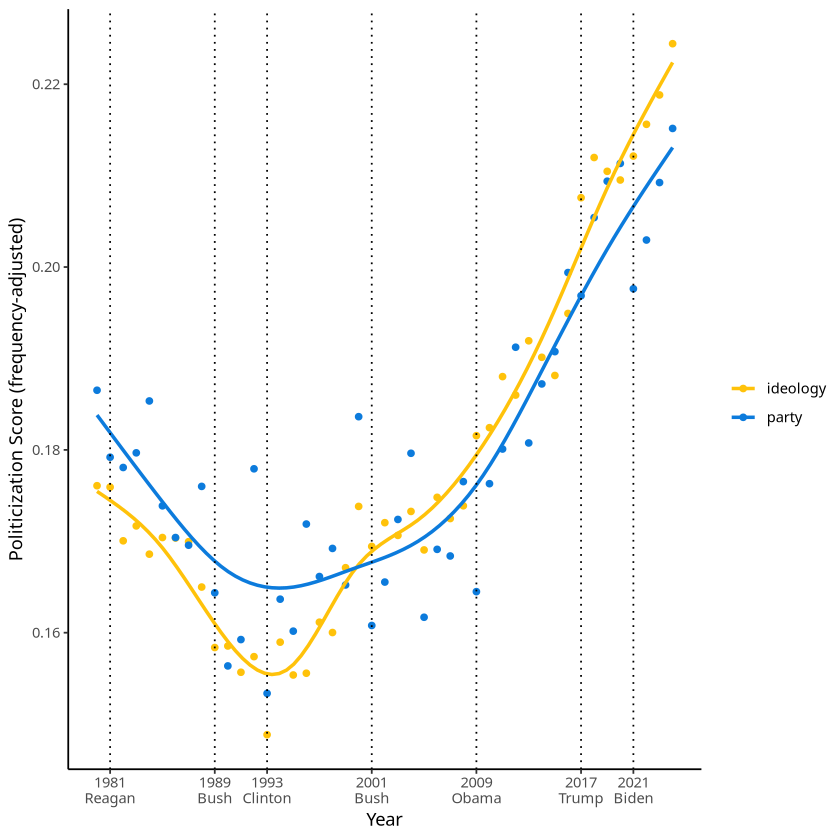

In [16]:
## Companion to Figure 1, using the frequency-adjusted score -- same spec, saved separately
results_df_cat_adj %>%
    group_by(year, group) %>%
    summarise(value_avg = mean(pol_score_adj, na.rm=TRUE)) %>%
    ungroup() %>%
    ggplot(aes(x= year, y=value_avg, color = group)) +
    geom_point() +
    geom_smooth(method = "gam", se=FALSE) +
    geom_vline(data = president, aes(xintercept = xintercepts), linetype = "dotted") +
    scale_x_continuous(
        breaks = c(1981, 1989, 1993, 2001, 2009, 2017, 2021),
        labels = c("1981\nReagan", "1989\nBush", "1993\nClinton",
                   "2001\nBush", "2009\nObama", "2017\nTrump", "2021\nBiden")) +
    scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
    theme_classic() +
    labs(x = "Year",
         y = "Politicization Score (frequency-adjusted)") + 
    guides(color = guide_legend(title = "")) +
    theme(plot.title = element_text(size= 20), 
          plot.subtitle=element_text(size=18), 
          strip.text = element_text(size = 15))

In [17]:
ggsave("FigureJ4_politicization_overall_freqadj.png")

Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


In [18]:
category_year_adj <- results_df_cat_adj %>%
  group_by(year, Category, group) %>%
  summarise(
    value_avg   = mean(pol_score_adj,       na.rm = TRUE),
    value_upper = mean(pol_score_upper_adj, na.rm = TRUE),
    value_lower = mean(pol_score_lower_adj, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(year0 = year - 1980)

head(category_year_adj)

year,Category,group,value_avg,value_upper,value_lower,year0
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1980,Animals,ideology,0.1791214,0.2029367,0.1546098,0
1980,Animals,party,0.1882578,0.2111247,0.1641531,0
1980,Creative Arts,ideology,0.1873080,0.2103704,0.1637964,0
1980,Creative Arts,party,0.1798993,0.2012929,0.1584434,0
1980,Crime and Policing,ideology,0.1571299,0.1792747,0.1335769,0
1980,Crime and Policing,party,0.1931248,0.2152688,0.1705090,0


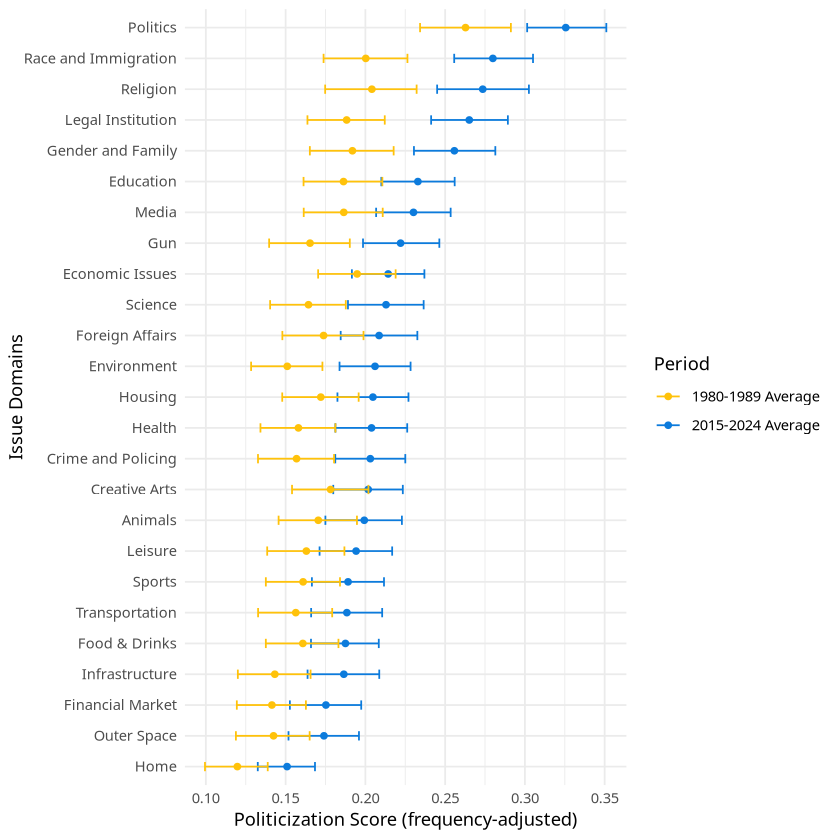

In [24]:
category_year_adj %>%
  group_by(Category) %>%
  filter(group == "ideology") %>%
  summarise(
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_upper = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  mutate(early_rank = min_rank(desc(early_value)),
         late_rank = min_rank(desc(late_value))) %>%
  ggplot(aes(y = reorder(Category, late_value))) +
  geom_point(aes(x = late_value, color = "2015-2024 Average"),
             position = position_dodge(width = 0.3)) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper,
                    color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper,
                    color = "1980-1989 Average"), width = 0.3) +
  scale_alpha_manual(values = c(0.5, 1.0)) +
  scale_linetype_manual(values = c("dashed", "solid")) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  labs(x = "Politicization Score (frequency-adjusted)",
       y = "Issue Domains") +
  guides(color = guide_legend(title = "Period")) +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(size= 20), 
          plot.subtitle=element_text(size=18), 
          strip.text = element_text(size = 15))

In [25]:
ggsave("FigureJ5_politicization_ideo_freqadjusted.png", width =6.5, height = 7)

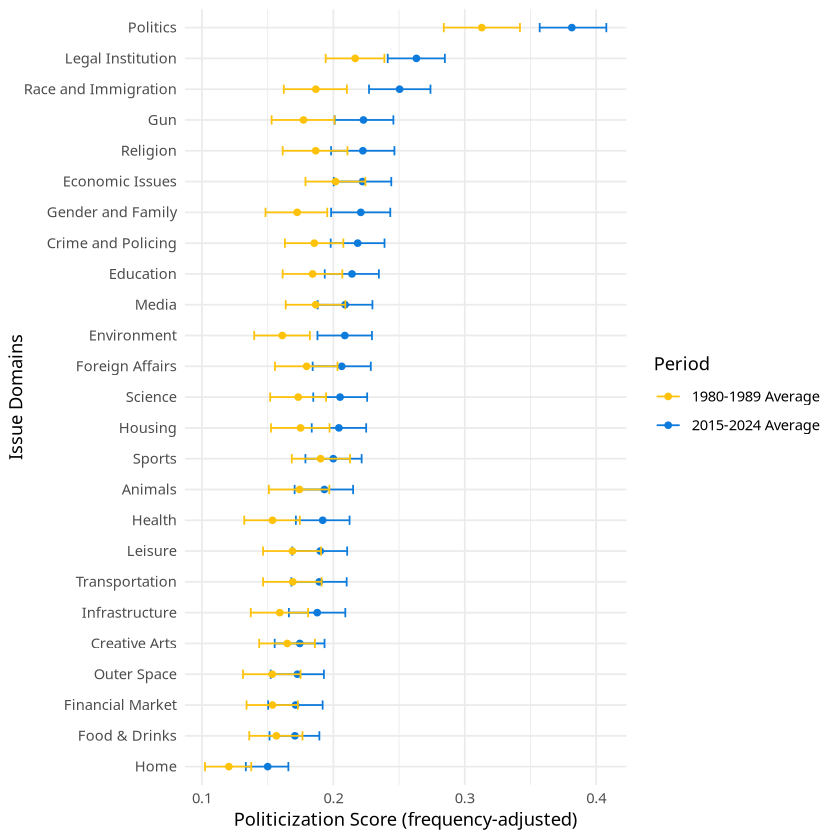

In [26]:
category_year_adj %>%
  group_by(Category) %>%
  filter(group == "party") %>%
  summarise(
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_upper = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  mutate(early_rank = min_rank(desc(early_value)),
         late_rank = min_rank(desc(late_value))) %>%
  ggplot(aes(y = reorder(Category, late_value))) +
  geom_point(aes(x = late_value, color = "2015-2024 Average"),
             position = position_dodge(width = 0.3)) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper,
                    color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper,
                    color = "1980-1989 Average"), width = 0.3) +
  scale_alpha_manual(values = c(0.5, 1.0)) +
  scale_linetype_manual(values = c("dashed", "solid")) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  labs(x = "Politicization Score (frequency-adjusted)",
       y = "Issue Domains") +
  guides(color = guide_legend(title = "Period")) +
  theme_minimal() +
  theme(plot.title = element_text(size= 20), 
          plot.subtitle=element_text(size=18), 
          strip.text = element_text(size = 15))

In [27]:
ggsave("FigureJ6_politicization_party_freqadjusted.png", width =6.5, height = 7)